[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/snuuq/ztm-tutorial/blob/main/week1/assignment.ipynb)

> **Colab 사용 시**: 열자마자 `파일 → Drive에 사본 저장`으로 사본을 만들어 작업하세요.
> 노트북이 만드는 파일(`pred_*.png`, `models/`)은 좌측 파일 패널에서 다운로드할 수 있고, 세션이 초기화되면 사라집니다.

# 1주차 과제 — 선형회귀 전 과정 직접 구현

1장에서 본 워크플로 6단계를 **다른 데이터로 처음부터 직접** 구현합니다.
교재 [Exercises](https://www.learnpytorch.io/01_pytorch_workflow/#exercises)를 기반으로 한 과제입니다.

## 해야 할 일
1. `w=0.7, b=0.3`으로 직선 데이터 생성, `torch.randperm`으로 랜덤 80:20 분할
2. `nn.Module` 상속 선형회귀 모델 작성
3. SGD로 300 epoch 학습, loss 곡선 그리기
4. 학습된 파라미터가 실제 `w, b`에 얼마나 가까운지 비교
5. 예측 vs 실제 산점도 (학습 전/후 2장 저장)
6. `state_dict`로 저장 → 로드 → 동일 예측 확인

## 규칙
- `# TODO` 부분을 채우세요. 그 외 제공 코드는 수정하지 않아도 됩니다.
- 재현성을 위해 시드는 제공된 값(2525)을 그대로 쓰세요.

## 0. 준비

Library import와 device 설정, 시드 고정.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(torch.__version__, "| device:", device)

RANDOM_SEED = 2525

2.13.0 | device: mps


## 1. 데이터 생성 & 랜덤 분할

`y = 0.7 * x + 0.3` 직선 데이터를 만들고 80:20으로 나눕니다.

교재(01장)는 앞 80%를 그대로 잘라 train으로 썼지만, 실전 데이터는 저장된 순서에 편향이 있을 수 있어(값 크기순 정렬, 수집 시점순 등) 보통 **인덱스를 랜덤하게 섞어서** 분할합니다. 여기서는 `torch.randperm`으로 직접 랜덤 분할을 구현합니다.

> 이 데이터에서 앞/뒤로 자르는 순차 분할을 쓰면 test는 $x \in [0.8, 1.0)$, 즉 학습 범위 **밖**(외삽, extrapolation)만 평가하게 됩니다. 랜덤 분할의 test는 무엇을 평가하게 될까요?

In [2]:
weight = 0.7
bias = 0.3

# TODO: X를 0부터 1까지 0.01 간격으로 만들고, 모델 입력 형태 (100, 1)이 되도록 하세요
X = torch.arange(0,1,0.01).reshape(100,1)
# TODO: y = weight * X + bias
y = weight * X +bias

# 랜덤 분할 — 재현성을 위해 셔플 직전에 시드를 고정합니다 (이 줄은 그대로 두세요)
torch.manual_seed(RANDOM_SEED)

# TODO: torch.randperm(len(X))으로 0~99를 뒤섞은 인덱스 텐서를 만들고, 앞 80개 인덱스를 train, 나머지 20개를 test로 나누세요
#       (힌트: index tensor로 바로 뽑을 수 있습니다. 예: X[train_idx])
indices = torch.randperm(len(X))
train_split = int(0.8 * len(X))
train_idx, test_idx = indices[:train_split], indices[train_split:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# 확인: 80 20
# print(len(X_train), len(X_test))
# 확인: 출력 결과가 오름차순, 내림차순 등 순차적인 출력만 아니면 됩니다.
# print(X_test)

In [3]:
# 확인: 80 20
print(len(X_train), len(X_test))
# 확인: 출력 결과가 오름차순, 내림차순 등 순차적인 출력만 아니면 됩니다.
print(X_test)

80 20
tensor([[0.5500],
        [0.0800],
        [0.3800],
        [0.8000],
        [0.9600],
        [0.6400],
        [0.6200],
        [0.6600],
        [0.7500],
        [0.8300],
        [0.5900],
        [0.2000],
        [0.9000],
        [0.9900],
        [0.3100],
        [0.0400],
        [0.9500],
        [0.5000],
        [0.1300],
        [0.7800]])


## 2. 데이터 시각화 (+ 학습 전 그래프는 5단계에서 저장)

시각화 함수는 제공합니다. 이후 예측 확인에 계속 사용합니다.

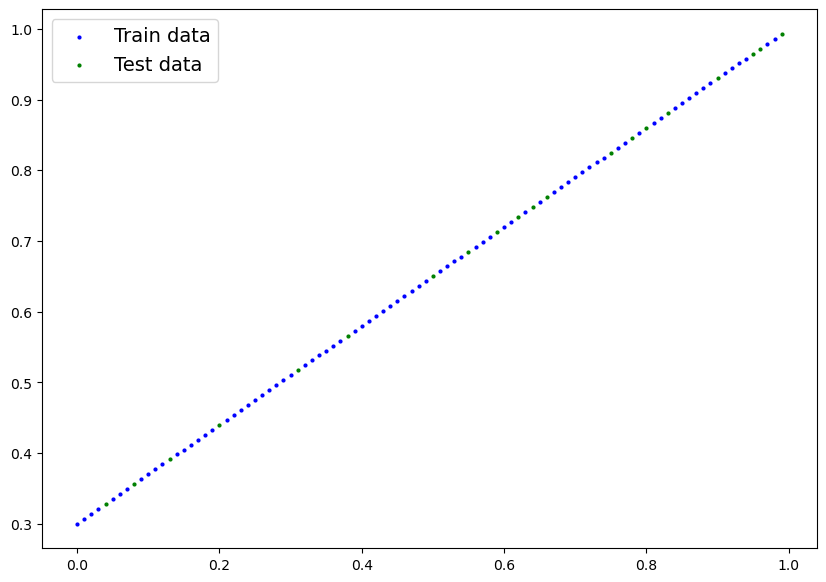

In [4]:
def plot_predictions(train_data=None, train_labels=None,
                     test_data=None, test_labels=None,
                     predictions=None, save_path=None):
    """학습/테스트 데이터와 (있다면) 예측값을 그립니다. save_path를 주면 파일로 저장합니다."""
    if train_data is None:
        train_data, train_labels = X_train, y_train
        test_data, test_labels = X_test, y_test
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Train data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={"size": 14})
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"그래프 저장: {save_path}")

plot_predictions()

## 3. 모델 정의

`nn.Module`을 상속해 선형회귀 모델을 만드세요. `nn.Parameter` 방식과 `nn.Linear` 방식 중 하나를 선택하면 됩니다.

In [5]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight=nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias=nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias


torch.manual_seed(RANDOM_SEED)
model = LinearRegressionModel()
print(model.state_dict())   # 랜덤 초기값 확인

OrderedDict([('weight', tensor([-1.1667])), ('bias', tensor([0.3909]))])


## 4. Loss function & Optimizer

- loss: `nn.L1Loss` (MAE)
- optimizer: `torch.optim.SGD`, `lr=0.05`

In [6]:
# TODO: loss_fn과 optimizer를 만드세요
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model.parameters(),lr=0.05)

## 5. 학습 전 예측 저장

랜덤 파라미터 상태의 예측을 `pred_before.png`로 저장합니다. 예측(빨강)이 정답(초록)에서 멀리 떨어져 있어도 정상입니다.

그래프 저장: pred_before.png


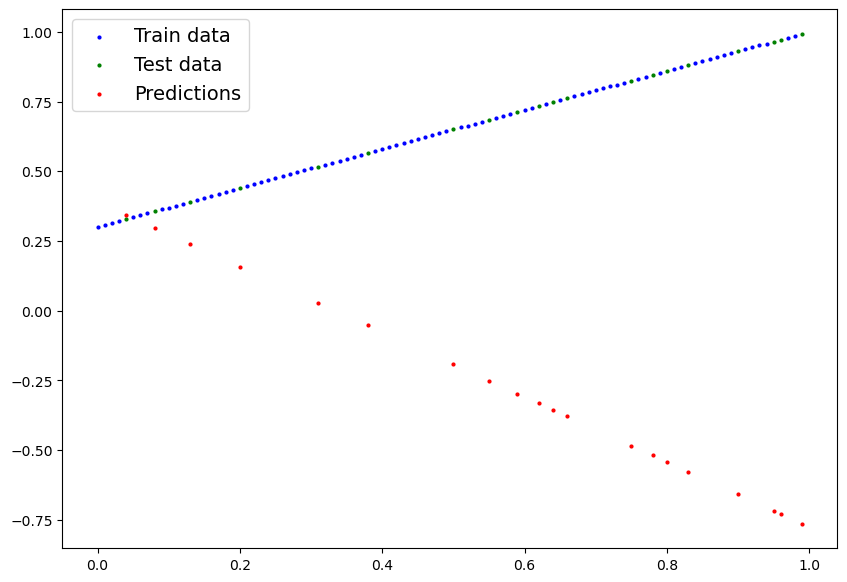

In [7]:
model.eval()
# TODO: inference_mode 안에서 X_test에 대한 예측을 구하세요
with torch.inference_mode():
    preds_before = model(X_test)

plot_predictions(predictions=preds_before, save_path="pred_before.png")

## 6. 학습 루프 — 300 epochs

학습 5단계(`forward → loss → zero_grad → backward → step`)를 채우고,
20 epoch마다 train/test loss를 기록·출력하세요.

In [8]:
torch.manual_seed(RANDOM_SEED)
epochs = 300

epoch_count, train_loss_values, test_loss_values = [], [], []

for epoch in range(epochs):
    ### 학습 ###
    model.train()

    # TODO: 학습 5단계
    # 1. forward pass
    y_pred=model(X_train)

    # 2. loss 계산
    loss=loss_fn(y_pred, y_train)

    # 3. gradient 초기화
    optimizer.zero_grad()

    # 4. backpropagation
    loss.backward()

    # 5. 파라미터 업데이트
    optimizer.step()


    ### 평가 ###
    model.eval()
    with torch.inference_mode():
        # TODO: test 예측과 test loss를 계산하세요
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test.type(torch.float))

    if epoch % 20 == 0:
        # TODO: 20 epoch마다 중간 학습 결과를 저장하고 출력하세요
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.7983299493789673 | Test loss: 0.944848358631134
Epoch: 20 | Train loss: 0.3635393977165222 | Test loss: 0.4483436644077301
Epoch: 40 | Train loss: 0.29689231514930725 | Test loss: 0.332577645778656
Epoch: 60 | Train loss: 0.2486063539981842 | Test loss: 0.2747073769569397
Epoch: 80 | Train loss: 0.2004968225955963 | Test loss: 0.22077341377735138
Epoch: 100 | Train loss: 0.1523883044719696 | Test loss: 0.16762660443782806
Epoch: 120 | Train loss: 0.10428197681903839 | Test loss: 0.11369259655475616
Epoch: 140 | Train loss: 0.05617566779255867 | Test loss: 0.05975857377052307
Epoch: 160 | Train loss: 0.008088787086308002 | Test loss: 0.0074281455017626286
Epoch: 180 | Train loss: 0.011528094299137592 | Test loss: 0.05327668786048889
Epoch: 200 | Train loss: 0.011528094299137592 | Test loss: 0.05327668786048889
Epoch: 220 | Train loss: 0.011528094299137592 | Test loss: 0.05327668786048889
Epoch: 240 | Train loss: 0.011528094299137592 | Test loss: 0.05327668786048

## 7. Loss 곡선

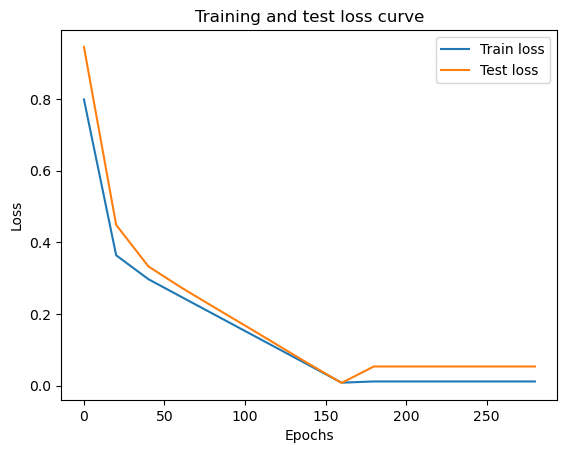

In [9]:
# TODO: epoch_count에 대해 train_loss_values와 test_loss_values를 그리세요
#       (제목, x/y 라벨, 범례 포함)
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

## 8. 파라미터 비교

학습된 파라미터가 실제 `weight=0.7, bias=0.3`에 얼마나 가까운지 출력하세요.

In [10]:
# TODO: model.state_dict()의 값과 정답(weight, bias)을 나란히 출력하고, 각 파라미터의 차이(절댓값)도 계산해 보세요.
print(model.state_dict())
print("weight 파라미터의 차이", model.weight-weight)
print("bias 파라미터의 차이", model.bias-bias)

OrderedDict([('weight', tensor([0.6908])), ('bias', tensor([0.3159]))])
weight 파라미터의 차이 tensor([-0.0092], grad_fn=<SubBackward0>)
bias 파라미터의 차이 tensor([0.0159], grad_fn=<SubBackward0>)


학습된 weight/bias가 정답과 차이가 [-0.0092,0.0159]로 모두 0.05 이내를 만족한다는 것을 알 수 있다.

## 9. 학습 후 예측 저장

학습 후 예측을 `pred_after.png`로 저장합니다. 예측(빨강)이 정답(초록)에 겹치면 성공입니다.

그래프 저장: pred_after.png


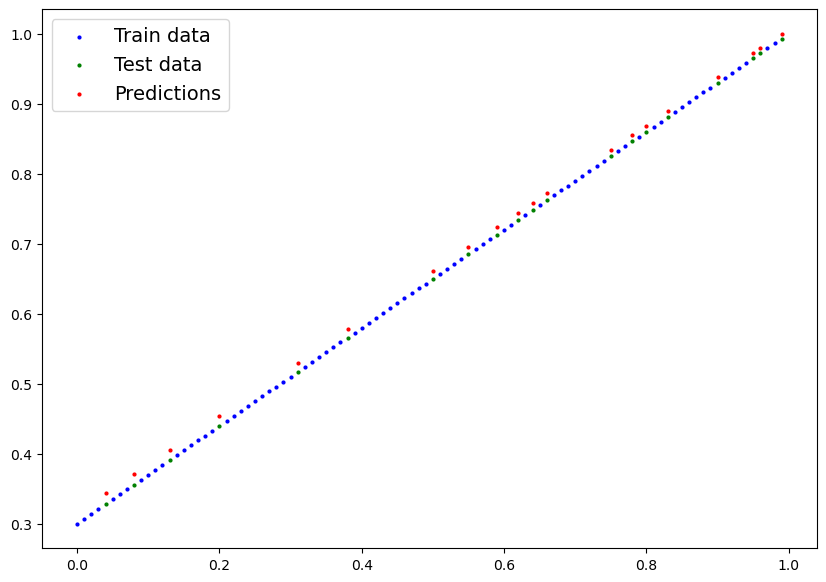

In [11]:
model.eval()
# TODO: 학습된 모델로 X_test 예측 → plot_predictions로 그려서 pred_after.png로 저장하세요
with torch.inference_mode():
    preds_after = model(X_test)

plot_predictions(predictions=preds_after, save_path="pred_after.png")

## 10. 저장 & 로드 & 검증

`state_dict`를 저장하고, 새 인스턴스에 로드한 뒤 **예측이 완전히 같은지** 확인하세요.

In [12]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / "week1_assignment_model.pth"

# TODO: 1) model의 state_dict를 MODEL_SAVE_PATH에 저장
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)
# TODO: 2) 새 LinearRegressionModel 인스턴스를 만들어 state_dict 로드
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

# TODO: 3) 로드한 모델의 예측이 preds_after와 같은지 확인 (또는 torch.isclose)
loaded_model.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model(X_test)
preds_after == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 11. (선택 도전) `nn.Linear` 버전

`nn.Linear(1, 1)`로 같은 모델을 다시 만들어 학습해 보고, 학습된 파라미터가 위와 비슷하게 나오는지 확인해 보세요.
그다음 `lr`을 0.1로 키워 다시 학습해 보세요. 더 빨리 수렴하나요, 아니면 loss가 어느 지점에서 더 안 내려가나요? 관찰한 것을 정리해보세요.

OrderedDict([('linear_layer.weight', tensor([[-0.3879]])), ('linear_layer.bias', tensor([0.7627]))])
Epoch: 0 | Train loss: 0.26527687907218933 | Test loss: 0.3171669840812683
Epoch: 20 | Train loss: 0.21099714934825897 | Test loss: 0.23284056782722473
Epoch: 40 | Train loss: 0.16289080679416656 | Test loss: 0.17890648543834686
Epoch: 60 | Train loss: 0.1147814616560936 | Test loss: 0.12497247755527496
Epoch: 80 | Train loss: 0.06667275726795197 | Test loss: 0.07182570546865463
Epoch: 100 | Train loss: 0.018566381186246872 | Test loss: 0.017891479656100273
Epoch: 120 | Train loss: 0.010127698071300983 | Test loss: 0.055127471685409546
Epoch: 140 | Train loss: 0.010127698071300983 | Test loss: 0.055127471685409546
Epoch: 160 | Train loss: 0.010127698071300983 | Test loss: 0.055127471685409546
Epoch: 180 | Train loss: 0.010127698071300983 | Test loss: 0.055127471685409546
Epoch: 200 | Train loss: 0.010127698071300983 | Test loss: 0.055127471685409546
Epoch: 220 | Train loss: 0.0101276980

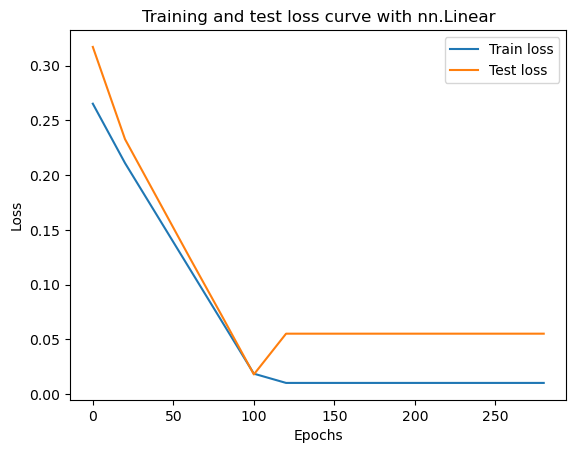

In [13]:
# 모델 정의
class LinearRegressionModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer=nn.Linear(in_features=1, out_features=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


torch.manual_seed(RANDOM_SEED)
model_2 = LinearRegressionModelV3()
print(model_2.state_dict())   

loss_fn_2 = nn.L1Loss()
optimizer_2 = torch.optim.SGD(params = model_2.parameters(),lr=0.05)

torch.manual_seed(RANDOM_SEED)
epochs = 300

epoch_count, train_loss_values, test_loss_values = [], [], []
for epoch in range(epochs):
    model_2.train()
    y_pred_2=model_2(X_train)
    loss_2=loss_fn_2(y_pred_2, y_train)
    optimizer_2.zero_grad()
    loss_2.backward()
    optimizer_2.step()

    model_2.eval()
    with torch.inference_mode():
        test_pred_2 = model_2(X_test)
        test_loss_2 = loss_fn_2(test_pred_2, y_test.type(torch.float))

    if epoch % 20 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss_2.detach().numpy())
        test_loss_values.append(test_loss_2.detach().numpy())
        print(f"Epoch: {epoch} | Train loss: {loss_2} | Test loss: {test_loss_2}")

print(model_2.state_dict())

plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curve with nn.Linear")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

위에랑 동일하게 하며 위에서는 nn.Parameter()을 이용하였고, nn.Linear을 이용해서 생성해본 결과, 학습된 파라미터의 결과와 유사하다는 것을 알 수 있다. 이 그래프에서는 epoch 0~100에서는 train/test loss가 계속 감소하며 epoch 100이후에는 두 평평해지고 그 이후에 변화가 없는 것처럼 보이므로 수렴했다고 볼 수 있다. 위의 모델보다 더 빠르게 수렴했다는 것을 알 수 있다.

OrderedDict([('linear_layer.weight', tensor([[-0.3879]])), ('linear_layer.bias', tensor([0.7627]))])
Epoch: 0 | Train loss: 0.26527687907218933 | Test loss: 0.3092006742954254
Epoch: 20 | Train loss: 0.1629103422164917 | Test loss: 0.1763746291399002
Epoch: 40 | Train loss: 0.06669769436120987 | Test loss: 0.06850650161504745
Epoch: 60 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 80 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 100 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 120 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 140 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 160 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 180 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 200 | Train loss: 0.029868613928556442 | Test loss: 0.09653151035308838
Epoch: 220 | Train loss: 0.029868613928556

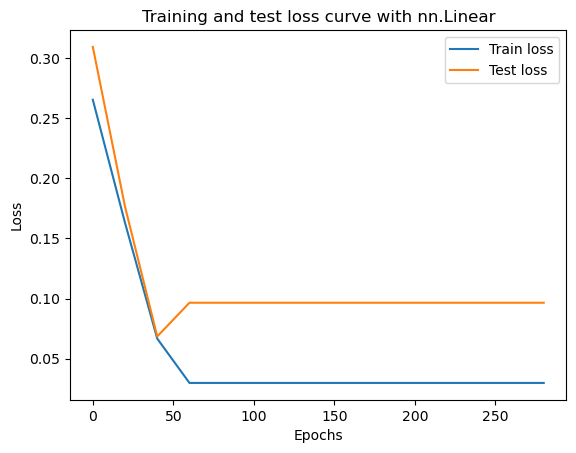

In [14]:
torch.manual_seed(RANDOM_SEED)
model_3 = LinearRegressionModelV3()
print(model_3.state_dict())   

loss_fn_3 = nn.L1Loss()
optimizer_3 = torch.optim.SGD(params = model_3.parameters(),lr=0.1)

torch.manual_seed(RANDOM_SEED)
epochs = 300

epoch_count, train_loss_values, test_loss_values = [], [], []
for epoch in range(epochs):
    model_3.train()
    y_pred_3=model_3(X_train)
    loss_3=loss_fn_3(y_pred_3, y_train)
    optimizer_3.zero_grad()
    loss_3.backward()
    optimizer_3.step()

    model_3.eval()
    with torch.inference_mode():
        test_pred_3 = model_3(X_test)
        test_loss_3 = loss_fn_3(test_pred_3, y_test.type(torch.float))

    if epoch % 20 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss_3.detach().numpy())
        test_loss_values.append(test_loss_3.detach().numpy())
        print(f"Epoch: {epoch} | Train loss: {loss_3} | Test loss: {test_loss_3}")

print(model_3.state_dict())

plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curve with nn.Linear")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

위 두 그래프를 비교해보면, 수렴속도는 lr=0.1인 경우 더 빨리 수렴한것을 알 수 있다. 하지만, 최종적으로 도달한 loss의 값은 lr 0.1일때가 더 높다는 것을 알 수 있다. 왜냐하면 ,lr가 크면 한스템에 파라미터가 움직이는 폭이 커져서 그 근처에서 멈춰버렸기 때문이다.

---

## 체크리스트

- [ ] 모든 셀이 위에서 아래로 에러 없이 실행됨 (로컬: `Kernel → Restart & Run All`, Colab: `런타임 → 세션 다시 시작 및 모두 실행`)
- [ ] `pred_before.png`, `pred_after.png` 2장이 생성됨
- [ ] loss 곡선에서 train/test loss가 함께 감소함
- [ ] 학습된 weight, bias가 0.7, 0.3에 근접함 (차이 0.05 이내 권장)
- [ ] 저장→로드 후 예측 동일 검증이 `True`